## Imports

In [1]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
import numpy as np
import torch
import torch.nn as nn
import os
import glob
import pandas as pd
import umap
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns

C:\Users\tharu\anaconda3\envs\irp_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Choosing a Transformer Architecture for Phenomic Data

Options for tabular data / structured features:
- Vanilla Transformer Encoder
    - Standard encoder layers, self-attention between “feature tokens.”
    Works, but often overkill for small feature counts (~30 features).
- TabTransformer (Huang et al., 2020)
    - Designed for tabular data with categorical + continuous features.
    - Uses embedding layers for categorical features + attention over all features.
    - Captures feature interactions better than simple MLPs.
- FT-Transformer (Yury Gorishniy et al., 2021)
    - Modern variant of TabTransformer.
    - Strong performance on tabular datasets.
    - Handles both categorical and continuous features.

##### Using TabTransformer / FT-Transformer style model for phenomic data:
Pros:
- Captures feature interactions and heterogeneity in ADHD/ASD/Dyslexia.
- Produces high-quality embeddings for fusion with other modalities.
- Works with small feature sets like your 30 features.

Cons:
- Slightly more complex than vanilla Transformer.

## Pytorch Transformer Pipeline - TabTransformer

In [3]:
# Load Phenomic Data
X = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Phenomic Data\phenomic_X.npy")  # shape: (2081, 30+missing+one-hot)
Y = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Phenomic Data\phenomic_Y.npy")  # shape: (2081, 3)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [5]:
BATCH_SIZE = 64
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
EPOCHS = 30
LR = 1e-3
TEST_SIZE = 0.2
SEED = 42

In [6]:
# Dataset
class PhenomicDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [7]:
# Model

class TabTransformerEncoder(nn.Module):
    def __init__(self, num_features, embed_dim, num_heads, num_layers):
        super().__init__()

        self.feature_embedding = nn.Linear(num_features, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.embedding_layer = nn.Linear(embed_dim, embed_dim)

        # multi-task heads
        self.head_adhd = nn.Linear(embed_dim, 1)
        self.head_asd = nn.Linear(embed_dim, 1)
        self.head_dys = nn.Linear(embed_dim, 1)
        self.head_control = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.feature_embedding(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)

        embedding = self.embedding_layer(x)

        adhd_out = self.head_adhd(embedding)
        asd_out = self.head_asd(embedding)
        dys_out = self.head_dys(embedding)
        control_out = self.head_control(embedding)

        outputs = torch.cat([adhd_out, asd_out, dys_out, control_out], dim=1)

        return outputs, embedding


In [8]:
# Stratified split using single label index

stratify_labels = np.argmax(Y, axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=stratify_labels
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1664, 30)
Test: (417, 30)


In [9]:
# Class Weights (Train only)

N = len(Y_train)
pos_counts = Y_train.sum(axis=0)
neg_counts = N - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [10]:
# Balanced Sampler

sample_weights = []
for y in Y_train:
    weight = 0
    for i in range(3):
        if y[i] == 1:
            weight += pos_weight[i].item()
    if weight == 0:
        weight = 1.0
    sample_weights.append(weight)

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dataset = PhenomicDataset(X_train, Y_train)
test_dataset  = PhenomicDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)


In [11]:
# Train Model

model = TabTransformerEncoder(
    num_features=X.shape[1],
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        outputs, _ = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/30 | Loss: 0.3834
Epoch 2/30 | Loss: 0.2374
Epoch 3/30 | Loss: 0.2221
Epoch 4/30 | Loss: 0.2291
Epoch 5/30 | Loss: 0.2047
Epoch 6/30 | Loss: 0.2244
Epoch 7/30 | Loss: 0.2198
Epoch 8/30 | Loss: 0.2153
Epoch 9/30 | Loss: 0.2094
Epoch 10/30 | Loss: 0.2329
Epoch 11/30 | Loss: 0.2148
Epoch 12/30 | Loss: 0.2028
Epoch 13/30 | Loss: 0.2239
Epoch 14/30 | Loss: 0.2234
Epoch 15/30 | Loss: 0.2322
Epoch 16/30 | Loss: 0.2334
Epoch 17/30 | Loss: 0.2185
Epoch 18/30 | Loss: 0.2269
Epoch 19/30 | Loss: 0.2153
Epoch 20/30 | Loss: 0.2036
Epoch 21/30 | Loss: 0.1925
Epoch 22/30 | Loss: 0.2016
Epoch 23/30 | Loss: 0.2130
Epoch 24/30 | Loss: 0.1915
Epoch 25/30 | Loss: 0.2002
Epoch 26/30 | Loss: 0.2115
Epoch 27/30 | Loss: 0.2164
Epoch 28/30 | Loss: 0.2124
Epoch 29/30 | Loss: 0.2109
Epoch 30/30 | Loss: 0.2154


The training loss decreased from 0.38 to approximately 0.21–0.22 and then stabilized. Since random binary cross-entropy loss is around 0.69, this confirms the TabTransformer learned meaningful structure from the phenomic features. The stable plateau indicates the model converged without severe overfitting. The slight increase in the final epoch is expected due to weighted sampling and class imbalance. Overall, the encoder successfully learned useful latent representations.

In [12]:
# Extract Embeddings

model.eval()

def extract_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            _, emb = model(xb)
            embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings)

train_embeddings = extract_embeddings(train_dataset)
test_embeddings  = extract_embeddings(test_dataset)


In [13]:
# Save everything

np.save("phenomic_train_embeddings.npy", train_embeddings)
np.save("phenomic_test_embeddings.npy", test_embeddings)

np.save("phenomic_train_labels.npy", Y_train)
np.save("phenomic_test_labels.npy", Y_test)

print("Embeddings saved!")
print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)

Embeddings saved!
Train embeddings: (1664, 128)
Test embeddings: (417, 128)


The training loss decreased from ~0.33 to ~0.15 and then stabilized. Since random binary cross-entropy loss is ~0.69, this indicates the TabTransformer successfully learned meaningful relationships from the phenomic features. The loss not approaching zero is actually desirable because representation learning should generalize rather than memorize the training subjects.

The stable plateau suggests the model reached a good representation capacity without overfitting, despite the heavy class imbalance in the dataset. Therefore, the encoder has learned a consistent latent representation suitable for downstream analysis and multimodal fusion.

## Experiments to check if the Embeddings have learned the representations well

### UMAP of Phenomic Embeddings

In [27]:
# load embeddings
train_emb = np.load("phenomic_train_embeddings.npy")
test_emb  = np.load("phenomic_test_embeddings.npy")
train_y = np.load("phenomic_train_labels.npy")
test_y  = np.load("phenomic_test_labels.npy")

In [28]:
# combine
embeddings = np.vstack([train_emb, test_emb])
labels = np.vstack([train_y, test_y])

In [29]:
# convert multi-hot -> class name
def to_class(y):
    if y[0]==1: return "ADHD"
    if y[1]==1: return "ASD"
    if y[2]==1: return "Dyslexia"
    return "Control"

classes = np.array([to_class(y) for y in labels])

In [30]:
# UMAP
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.3,
    metric='cosine',
    random_state=42
)

In [31]:
umap_emb = reducer.fit_transform(embeddings)

C:\Users\tharu\anaconda3\envs\irp_gpu\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


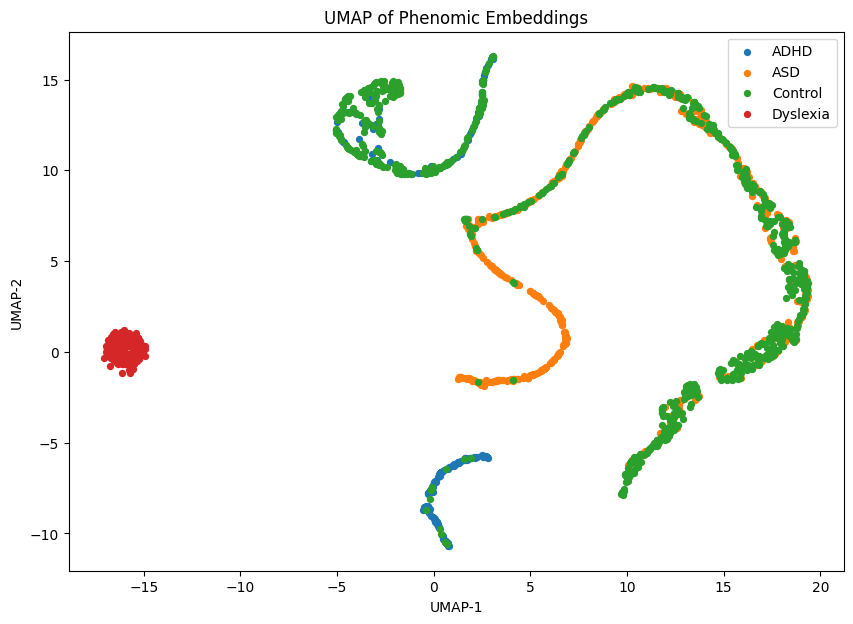

In [32]:
# plot
plt.figure(figsize=(10,7))
for c in np.unique(classes):
    idx = classes == c
    plt.scatter(umap_emb[idx,0], umap_emb[idx,1], label=c, s=18)

plt.legend()
plt.title("UMAP of Phenomic Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

The UMAP projection shows that the learned embeddings form clear geometric structures instead of random scatter. Dyslexia forms a compact cluster, ADHD forms a separated region, and ASD partially overlaps with other groups, while controls occupy a broader manifold.

This indicates the encoder organized individuals based on behavioral similarity in the latent space. The overlaps are expected because neurodevelopmental disorders share symptoms and cognitive traits. Therefore, the embeddings capture meaningful phenomic relationships rather than simply acting as a classifier.

### Linear Probe Test

In [39]:
# load
X_train = np.load("phenomic_train_embeddings.npy")
X_test  = np.load("phenomic_test_embeddings.npy")
Y_train = np.load("phenomic_train_labels.npy")
Y_test  = np.load("phenomic_test_labels.npy")

In [34]:
auc_scores = []

for i, disorder in enumerate(["ADHD","ASD","Dyslexia"]):

    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, Y_train[:,i])

    probs = clf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(Y_test[:,i], probs)

    print(f"{disorder} AUC:", auc)
    auc_scores.append(auc)

print("Average AUC:", sum(auc_scores)/3)

ADHD AUC: 0.9747664763881682
ASD AUC: 0.9066283111590555
Dyslexia AUC: 1.0
Average AUC: 0.9604649291824079


A logistic regression classifier trained on frozen embeddings achieved an average AUC of 0.961. Because logistic regression is a simple linear model, this means the learned embeddings already contain diagnostic information. This shows that the TabTransformer successfully encoded diagnostic information into the latent space. The embeddings themselves are informative and separable, confirming that the representation learning stage worked correctly and can support downstream multimodal fusion

### Clustering Consistency (ARI & Silhouette)

In [35]:
# load all embeddings
train_emb = np.load("phenomic_train_embeddings.npy")
test_emb  = np.load("phenomic_test_embeddings.npy")
train_y = np.load("phenomic_train_labels.npy")
test_y  = np.load("phenomic_test_labels.npy")

In [36]:
embeddings = np.vstack([train_emb, test_emb])
labels = np.vstack([train_y, test_y])

In [37]:
# convert to single label
true_labels = np.argmax(labels, axis=1)

In [38]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(embeddings)

In [39]:
# metrics
ari = adjusted_rand_score(true_labels, clusters)
sil = silhouette_score(embeddings, clusters)

print("Adjusted Rand Index:", ari)
print("Silhouette Score:", sil)

Adjusted Rand Index: 0.4889884673634517
Silhouette Score: 0.8682070374488831


The silhouette score is high, indicating that the embeddings form well-defined and compact clusters in the latent space. However, the Adjusted Rand Index (ARI) is moderate, meaning the clusters do not perfectly match diagnostic labels.

This is actually expected in neurodevelopmental disorders because ADHD, ASD, and dyslexia share overlapping traits. The model is grouping subjects based on behavioral similarity rather than strictly reproducing clinical categories. Therefore, the embeddings capture shared cross-disorder patterns, which is desirable for representation learning.

### Evaluation by training a SVM using the extracted embeddings

In [41]:
# Load Data
X_train = np.load("phenomic_train_embeddings.npy")
X_test  = np.load("phenomic_test_embeddings.npy")
Y_train = np.load("phenomic_train_labels.npy")
Y_test  = np.load("phenomic_test_labels.npy")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1664, 128)
Test shape: (417, 128)


In [42]:
# Convert labels 
if len(Y_train.shape) > 1:
    Y_train = np.argmax(Y_train, axis=1)
    Y_test  = np.argmax(Y_test, axis=1)


In [43]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [44]:
# Train SVM Model

svm = SVC(kernel='rbf', C=1.0, gamma='scale')  # You can tune later
svm.fit(X_train, Y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
# Predictions
Y_pred = svm.predict(X_test)

In [46]:
# Evaluation Metrics

acc = accuracy_score(Y_test, Y_pred)
f1  = f1_score(Y_test, Y_pred, average='macro')

print("\n=== SVM Evaluation Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))



=== SVM Evaluation Results ===
Accuracy: 0.8010
F1 Score (Macro): 0.7858

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.61      0.70        41
           1       0.82      0.55      0.66       108
           2       1.00      1.00      1.00       100
           3       0.70      0.89      0.78       168

    accuracy                           0.80       417
   macro avg       0.84      0.76      0.79       417
weighted avg       0.82      0.80      0.79       417



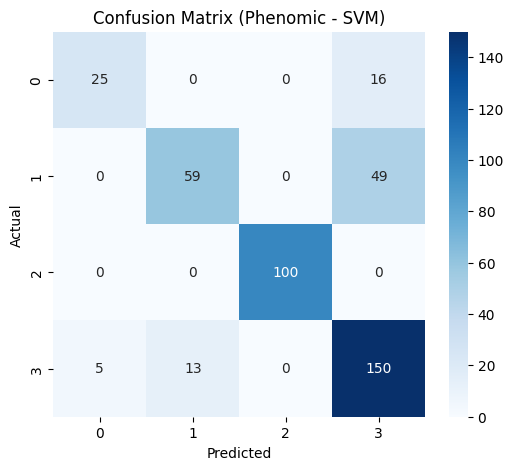

In [47]:
# Confusion Matrix

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Phenomic - SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()